# ANN from Scratch in NumPy
Binary classification on `make_moons`. No PyTorch, no Keras — raw numpy all the way.

**Flow:** Dataset → Activations → Init → Forward → Loss → Backward → Update → Train → Evaluate

## 1. Imports

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

np.random.seed(42)

## 2. Dataset

`make_moons` gives two interleaved half-circles — linearly non-separable, so it forces the network to learn a non-linear decision boundary. Perfect for validating that backprop actually works.

Shape convention throughout: **(features, samples)** — i.e. `X.shape = (n_x, m)`. This keeps matrix math clean: `W @ X` without transposing everywhere.

X_tr: (2, 800)  y_tr: (1, 800)
X_val: (2, 200)  y_val: (1, 200)


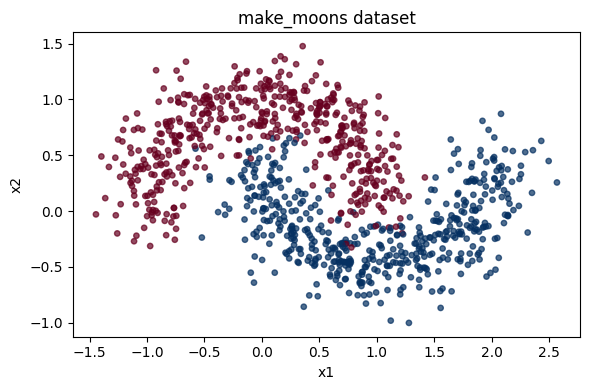

In [5]:
X_raw, y_raw = make_moons(n_samples=1000, noise=0.2, random_state=42)

# (m, n_x) -> (n_x, m)  |  (m,) -> (1, m)
X_all = X_raw.T          # shape: (2, 1000)
y_all = y_raw.reshape(1, -1)  # shape: (1, 1000)

# Train/val split (keeping columnar layout)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_all.T, y_all.T, test_size=0.2, random_state=42
)
X_tr, X_val = X_tr.T, X_val.T
y_tr, y_val = y_tr.T, y_val.T

print(f"X_tr: {X_tr.shape}  y_tr: {y_tr.shape}")
print(f"X_val: {X_val.shape}  y_val: {y_val.shape}")

# Visualize
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(*X_all, c=y_all.squeeze(), cmap='RdBu', s=15, alpha=0.7)
ax.set_title('make_moons dataset')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
plt.tight_layout(); plt.show()

## 3. Activation Functions

Each activation needs:
- **forward**: compute output given `Z`  
- **backward**: compute `dZ` given `dA` (chain rule: `dZ = dA * f'(Z)`)

We cache `Z` during forward pass so we can reuse it during backprop.

In [6]:
def relu(Z):
    return np.maximum(0, Z)

def relu_backward(dA, Z):
    # derivative: 1 where Z > 0, else 0
    dZ = dA * (Z > 0).astype(float)
    return dZ

def sigmoid(Z):
    # clipped for numerical stability
    Z = np.clip(Z, -500, 500)
    return 1 / (1 + np.exp(-Z))

def sigmoid_backward(dA, Z):
    s = sigmoid(Z)
    dZ = dA * s * (1 - s)
    return dZ

ACTIVATIONS = {
    'relu':    (relu,    relu_backward),
    'sigmoid': (sigmoid, sigmoid_backward),
}

# Quick sanity check
Z_test = np.array([-2., 0., 2.])
print('ReLU:   ', relu(Z_test))
print('Sigmoid:', sigmoid(Z_test).round(4))

ReLU:    [0. 0. 2.]
Sigmoid: [0.1192 0.5    0.8808]


## 4. Weight Initialization

**He initialization** for ReLU layers: `W ~ N(0, sqrt(2/n_prev))`.  
Prevents vanishing/exploding gradients at the start of training.

`layer_dims` = list of layer sizes including input.  
e.g. `[2, 16, 8, 1]` → input(2) → hidden(16) → hidden(8) → output(1)

In [7]:
def init_params(layer_dims):
    """
    Returns dict: {W1, b1, W2, b2, ...}
    W[l].shape = (layer_dims[l], layer_dims[l-1])
    b[l].shape = (layer_dims[l], 1)
    """
    params = {}
    L = len(layer_dims) - 1  # number of layers (excluding input)
    for l in range(1, L + 1):
        n_curr, n_prev = layer_dims[l], layer_dims[l - 1]
        params[f'W{l}'] = np.random.randn(n_curr, n_prev) * np.sqrt(2 / n_prev)  # He init
        params[f'b{l}'] = np.zeros((n_curr, 1))
    return params

# Check shapes
test_params = init_params([2, 16, 8, 1])
for k, v in test_params.items():
    print(f"{k}: {v.shape}")

W1: (16, 2)
b1: (16, 1)
W2: (8, 16)
b2: (8, 1)
W3: (1, 8)
b3: (1, 1)


## 5. Forward Pass

For each layer `l`:
```
Z[l] = W[l] @ A[l-1] + b[l]      # linear
A[l] = f(Z[l])                    # activation
```

We cache `(A_prev, W, b, Z)` per layer — needed during backprop.

In [8]:
def forward_pass(X, params, activations):
    """
    X          : input (n_x, m)
    params     : dict of W1,b1,W2,b2,...
    activations: list of activation names, length = num_layers
                 e.g. ['relu', 'relu', 'sigmoid']

    Returns:
        AL     : final output (n_out, m)
        caches : list of (A_prev, W, b, Z) per layer
    """
    caches = []
    A = X
    L = len(activations)

    for l in range(1, L + 1):
        A_prev = A
        W = params[f'W{l}']
        b = params[f'b{l}']

        Z = W @ A_prev + b                          # (n_l, m)
        act_fn, _ = ACTIVATIONS[activations[l - 1]]
        A = act_fn(Z)

        caches.append((A_prev, W, b, Z))            # save for backprop

    return A, caches  # AL = A after last layer


# Smoke test
test_p = init_params([2, 16, 8, 1])
AL, caches = forward_pass(X_tr, test_p, ['relu', 'relu', 'sigmoid'])
print(f"Output AL shape: {AL.shape}  min: {AL.min():.3f}  max: {AL.max():.3f}")

Output AL shape: (1, 800)  min: 0.139  max: 0.816


## 6. Loss — Binary Cross-Entropy

$$\mathcal{L} = -\frac{1}{m} \sum \left[ y \log(\hat{y}) + (1-y) \log(1-\hat{y}) \right]$$

The `1e-8` clip prevents `log(0)`.

In [9]:
def compute_loss(AL, Y):
    m = Y.shape[1]
    AL = np.clip(AL, 1e-8, 1 - 1e-8)
    loss = -np.sum(Y * np.log(AL) + (1 - Y) * np.log(1 - AL)) / m
    return float(loss)

print(f"Initial loss: {compute_loss(AL, y_tr):.4f}")

Initial loss: 0.4771


## 7. Backward Pass

In [ ]:
def backward_pass(AL, Y, caches, activations):
    """
    Returns grads dict: {dW1, db1, dW2, db2, ...}
    """
    grads = {}
    L = len(caches)
    m = Y.shape[1]

    # Seed: dL/dAL for binary cross-entropy
    AL_clipped = np.clip(AL, 1e-8, 1 - 1e-8)
    dA = -(Y / AL_clipped) + (1 - Y) / (1 - AL_clipped)  # (1, m)

    for l in reversed(range(L)):          # L-1 down to 0
        A_prev, W, b, Z = caches[l]
        _, act_bwd = ACTIVATIONS[activations[l]]

        dZ = act_bwd(dA, Z)               # (n_l, m)
        grads[f'dW{l+1}'] = (dZ @ A_prev.T) / m   # (n_l, n_{l-1})
        grads[f'db{l+1}'] = np.sum(dZ, axis=1, keepdims=True) / m  # (n_l, 1)
        dA = W.T @ dZ                     # pass to previous layer: (n_{l-1}, m)

    return grads

dW3: (1, 8)
db3: (1, 1)
dW2: (8, 16)
db2: (8, 1)
dW1: (16, 2)
db1: (16, 1)


## 8. Parameter Update — SGD

$$W^{[l]} \leftarrow W^{[l]} - \alpha \cdot dW^{[l]}$$
$$b^{[l]} \leftarrow b^{[l]} - \alpha \cdot db^{[l]}$$

In [11]:
def update_params(params, grads, lr):
    L = len(params) // 2  # number of layers
    for l in range(1, L + 1):
        params[f'W{l}'] -= lr * grads[f'dW{l}']
        params[f'b{l}'] -= lr * grads[f'db{l}']
    return params

## 9. Training Loop

In [ ]:
def get_mini_batches(X, Y, batch_size):
    m = X.shape[1]
    perm = np.random.permutation(m)
    X, Y = X[:, perm], Y[:, perm]
    batches = []
    for i in range(0, m, batch_size):
        batches.append((X[:, i:i+batch_size], Y[:, i:i+batch_size]))
    return batches


def train(X_tr, y_tr, X_val, y_val, layer_dims, activations,
          lr=0.01, epochs=500, batch_size=64, print_every=100):

    params = init_params(layer_dims)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        # mini-batch loop 
        epoch_loss = 0
        batches = get_mini_batches(X_tr, y_tr, batch_size)
        for Xb, Yb in batches:
            AL, caches = forward_pass(Xb, params, activations)
            epoch_loss += compute_loss(AL, Yb)
            grads = backward_pass(AL, Yb, caches, activations)
            params = update_params(params, grads, lr)

        # record metrics (full pass, no grad) 
        AL_tr,  _ = forward_pass(X_tr,  params, activations)
        AL_val, _ = forward_pass(X_val, params, activations)

        t_loss = compute_loss(AL_tr,  y_tr)
        v_loss = compute_loss(AL_val, y_val)
        t_acc  = np.mean((AL_tr  > 0.5) == y_tr)
        v_acc  = np.mean((AL_val > 0.5) == y_val)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        if epoch % print_every == 0:
            print(f"Epoch {epoch:4d} | loss {t_loss:.4f} | val_loss {v_loss:.4f} "
                  f"| acc {t_acc:.3f} | val_acc {v_acc:.3f}")

    return params, history

In [13]:
# Architecture: input(2) -> 16 -> 8 -> output(1)
layer_dims  = [2, 16, 8, 1]
activations = ['relu', 'relu', 'sigmoid']  # len = num_layers

params, history = train(
    X_tr, y_tr, X_val, y_val,
    layer_dims  = layer_dims,
    activations = activations,
    lr          = 0.05,
    epochs      = 1000,
    batch_size  = 64,
    print_every = 200,
)

Epoch  200 | loss 0.0780 | val_loss 0.0598 | acc 0.973 | val_acc 0.980
Epoch  400 | loss 0.0632 | val_loss 0.0463 | acc 0.974 | val_acc 0.985
Epoch  600 | loss 0.0617 | val_loss 0.0338 | acc 0.978 | val_acc 0.995
Epoch  800 | loss 0.0598 | val_loss 0.0442 | acc 0.978 | val_acc 0.985
Epoch 1000 | loss 0.0637 | val_loss 0.0589 | acc 0.970 | val_acc 0.965


In [18]:
def count_params(params):
    total = 0
    for k, v in params.items():
        n = v.size
        print(f"{k}: {v.shape} -> {n:,}")
        total += n
    print(f"\nTotal trainable params: {total:,}")

count_params(params)

W1: (16, 2) -> 32
b1: (16, 1) -> 16
W2: (8, 16) -> 128
b2: (8, 1) -> 8
W3: (1, 8) -> 8
b3: (1, 1) -> 1

Total trainable params: 193


## 10. Visualize Training

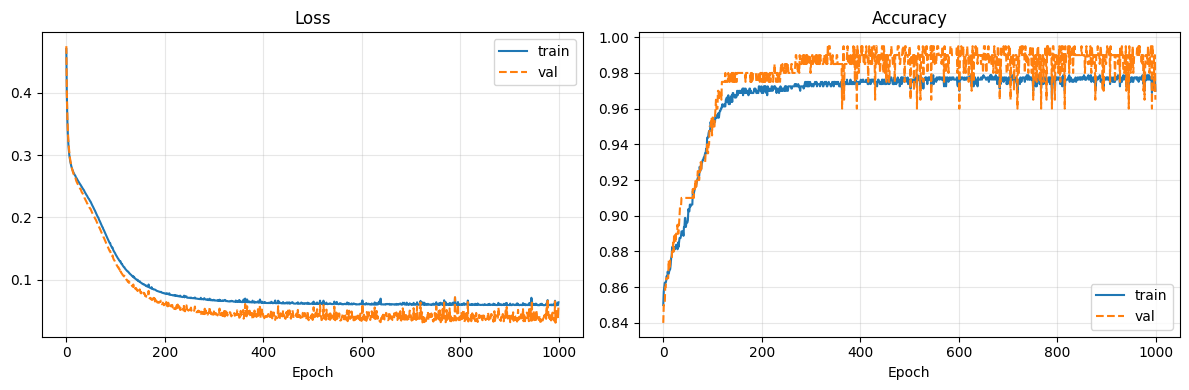

Final val accuracy: 96.5%


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'],   label='val', linestyle='--')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='train')
axes[1].plot(history['val_acc'],   label='val', linestyle='--')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Final val accuracy: {history['val_acc'][-1]*100:.1f}%")

## 11. Decision Boundary

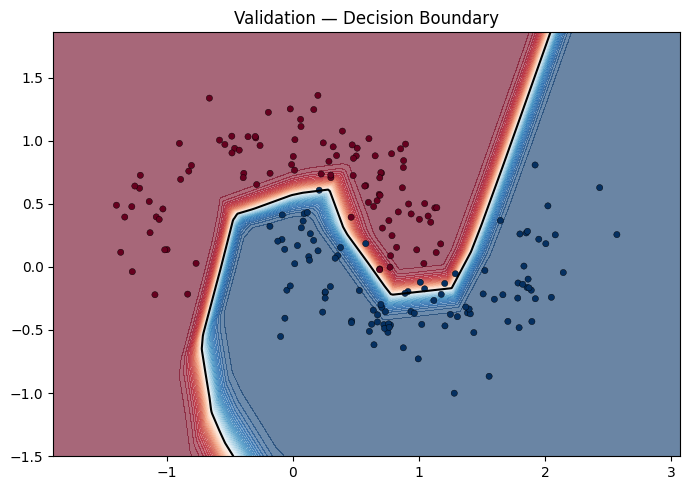

In [15]:
def plot_decision_boundary(X, Y, params, activations, title='Decision Boundary'):
    x_min, x_max = X[0].min() - 0.5, X[0].max() + 0.5
    y_min, y_max = X[1].min() - 0.5, X[1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()].T          # (2, 90000)
    probs, _ = forward_pass(grid, params, activations)
    Z = probs.reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=1.5)
    ax.scatter(*X, c=Y.squeeze(), cmap='RdBu', s=20, edgecolors='k', linewidths=0.3)
    ax.set_title(title)
    plt.tight_layout(); plt.show()

plot_decision_boundary(X_val, y_val, params, activations, 'Validation — Decision Boundary')

## 12. Experiment — Compare Architectures

Sanity check: a deeper network should fit moons better than a shallow one.

Shallow (4)          -> val_acc: 89.0%
Medium (16-8)        -> val_acc: 98.5%
Deep (32-16-8)       -> val_acc: 98.5%


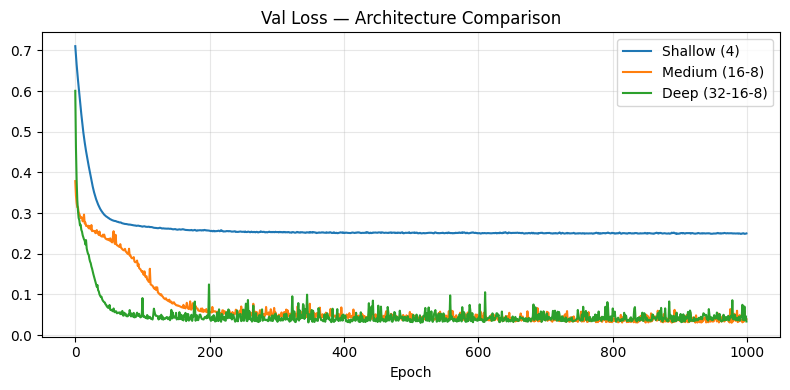

In [17]:
configs = [
    {'layer_dims': [2, 4, 1],        'activations': ['relu', 'sigmoid'],          'label': 'Shallow (4)'},
    {'layer_dims': [2, 16, 8, 1],    'activations': ['relu', 'relu', 'sigmoid'],  'label': 'Medium (16-8)'},
    {'layer_dims': [2, 32, 16, 8, 1],'activations': ['relu', 'relu', 'relu', 'sigmoid'], 'label': 'Deep (32-16-8)'},
]

results = []
for cfg in configs:
    p, h = train(
        X_tr, y_tr, X_val, y_val,
        layer_dims=cfg['layer_dims'], activations=cfg['activations'],
        lr=0.05, epochs=1000, batch_size=64, print_every=9999
    )
    final_val_acc = h['val_acc'][-1]
    print(f"{cfg['label']:20s} -> val_acc: {final_val_acc*100:.1f}%")
    results.append((cfg['label'], h, p, cfg['activations']))

# Plot loss curves side by side
fig, ax = plt.subplots(figsize=(8, 4))
for label, h, _, _ in results:
    ax.plot(h['val_loss'], label=label)
ax.set_title('Val Loss — Architecture Comparison')
ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()